In [1]:
import os
import sys
import random
import optuna
import numpy as np
import pandas as pd
from dotenv import load_dotenv

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask, add_week_column, objective
from etl_pipeline_local import get_multigoal_24_table

sys.path.append("../..")
from strategies.utils import analyze_strategies, get_best_strategies

from utils import trial_key, run_one_study
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.INFO)

load_dotenv()

True

In [2]:
# TODO: far scegliere a Optuna se tenere o meno una variabile
# TODO: aggiungere early stopping
# TODO: perfezionare funzione di costo per tradeoff roi medio e quantità di partite considerate
# TODO: analisi  univariata KPI più promettenti (Optional)

# 1. Load Data

In [ ]:
# Bet setup
target_col = "multigoal_24"
odds_col: str = "multigoal_24_odds"

# Load data
df_loaded = get_multigoal_24_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
df[odds_col] = 1.53
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df["chance1x2_xg_diff"] = abs(df["chance1x2_xg_home"] - df["chance1x2_xg_away"])

# Train/test split
df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

## 2. Define Parameters

In [39]:
# Define features and relative step

feature_bins_map = {
    'evaluation_valUnderOver': None,
    'goalNoGoal_chance_goalHome': 5,
    'goalNoGoal_chance_goalAway': 5,
    'goalNoGoal_multigoal_m24': 5,
    # 'goalNoGoal_quote_diffInitialCurrGG': 5,
    'goalNoGoal_comparison_affini': 500,
    'goalNoGoal_comparison_flashback': 250,
    'goalNoGoal_flashback_m24': 5,
    # 'underOver_chance_over15': 5,
    # 'underOver_comparison_affini': 1000,
    # 'underOver_comparison_flashback': 200,
    # 'underOver_flashback_over15': 4,
    # 'chance1x2_xg_home': 0.1,
    # 'chance1x2_xg_away': 0.1,
    # 'chance1x2_xg_total':0.1,
}
objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 5, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}


# Create the binned dataframe
df_train_binned = df_train.copy()

for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: evaluation_valUnderOver
Search space: ['560002' '560003' '776652' '777613' '931281' '932242']


Feature: goalNoGoal_chance_goalHome
Search space: <IntegerArray>
[0, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
Length: 19, dtype: Int64


Feature: goalNoGoal_chance_goalAway
Search space: <IntegerArray>
[0, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95,
 100]
Length: 20, dtype: Int64


Feature: goalNoGoal_multigoal_m24
Search space: <IntegerArray>
[25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]
Length: 12, dtype: Int64


Feature: goalNoGoal_comparison_affini
Search space: <IntegerArray>
[    0,   500,  1000,  1500,  3000,  3500,  4000,  4500,  5000,  7000,  7500,
  8000,  8500,  9000,  9500, 10000, 10500, 11000, 11500, 12000, 12500, 13000,
 13500, 14000, 14500, 15000, 15500, 16000, 16500, 17000, 17500, 18000, 18500,
 19000, 19500, 20000, 20500, 21000, 21500, 22000, 22500]
Length: 41, dtype: Int64


Feature: goalN

## 3. Optimize

In [40]:
# Generate random seeds
seeds = [random.randint(0, 2**32 - 1) for _ in range(objective_hyperparameters["n_studies"])]
studies = [
    run_one_study(
        seed=s, 
        objective_hyperparameters=objective_hyperparameters, 
        objective=objective,
        feature_bins_map=feature_bins_map, 
        df_binned=df_train_binned
        ) 
        for s in seeds]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)
best_trials = top_trials[:10]
print(best_trials)

[I 2026-04-04 15:06:39,801] A new study created in memory with name: no-name-6d783144-288a-459d-b134-a1352589d109
[I 2026-04-04 15:06:39,805] Trial 0 pruned. 
[I 2026-04-04 15:06:39,810] Trial 1 pruned. 
[I 2026-04-04 15:06:39,815] Trial 2 pruned. 
[I 2026-04-04 15:06:39,820] Trial 3 pruned. 
[I 2026-04-04 15:06:39,823] Trial 4 pruned. 
[I 2026-04-04 15:06:39,826] Trial 5 pruned. 
[I 2026-04-04 15:06:39,835] Trial 6 finished with value: -1000000000.0 and parameters: {'evaluation_valUnderOver_cat_idx': 44, 'goalNoGoal_chance_goalHome_use_min': False, 'goalNoGoal_chance_goalHome_use_max': True, 'goalNoGoal_chance_goalHome_min': 5, 'goalNoGoal_chance_goalHome_max': 10, 'goalNoGoal_chance_goalAway_use_min': True, 'goalNoGoal_chance_goalAway_use_max': False, 'goalNoGoal_chance_goalAway_min': 0, 'goalNoGoal_chance_goalAway_max': 30, 'goalNoGoal_multigoal_m24_use_min': True, 'goalNoGoal_multigoal_m24_use_max': True, 'goalNoGoal_multigoal_m24_min': 25, 'goalNoGoal_multigoal_m24_max': 65, 'goal

[FrozenTrial(number=457, state=<TrialState.COMPLETE: 1>, values=[-1.346226479436569], datetime_start=datetime.datetime(2026, 4, 4, 15, 7, 15, 57728), datetime_complete=datetime.datetime(2026, 4, 4, 15, 7, 15, 113059), params={'evaluation_valUnderOver_cat_idx': 25, 'goalNoGoal_chance_goalHome_use_min': True, 'goalNoGoal_chance_goalHome_use_max': True, 'goalNoGoal_chance_goalHome_min': 60, 'goalNoGoal_chance_goalHome_max': 100, 'goalNoGoal_chance_goalAway_use_min': False, 'goalNoGoal_chance_goalAway_use_max': True, 'goalNoGoal_chance_goalAway_min': 10, 'goalNoGoal_chance_goalAway_max': 50, 'goalNoGoal_multigoal_m24_use_min': True, 'goalNoGoal_multigoal_m24_use_max': True, 'goalNoGoal_multigoal_m24_min': 55, 'goalNoGoal_multigoal_m24_max': 75, 'goalNoGoal_comparison_affini_use_min': False, 'goalNoGoal_comparison_affini_use_max': True, 'goalNoGoal_comparison_affini_min': 1000, 'goalNoGoal_comparison_affini_max': 14000, 'goalNoGoal_comparison_flashback_use_min': False, 'goalNoGoal_compariso

## 4. Evaluate

In [41]:
# Create the test binned dataframe
return_threshold = -5.
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = best_trials[i].user_attrs["params_dict"]

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_return = df.groupby('week')['return'].sum().min()
    max_return = df.groupby('week')['return'].sum().max()

    if min_return >= return_threshold:
        print(f"Trial no. {i}")
        print(f"Min return {min_return}")
        print(f"Max return {max_return}")
        print(f"Score {trial.value}")
        print("\n")

Trial no. 0
Min return -3.4699999999999998
Max return 2.18
Score -1.346226479436569


Trial no. 1
Min return -3.4699999999999998
Max return 2.18
Score -1.346226479436569


Trial no. 2
Min return -3.4699999999999998
Max return 2.18
Score -1.348008032877371


Trial no. 3
Min return -3.4699999999999998
Max return 2.18
Score -1.348008032877371


Trial no. 4
Min return -3.0
Max return 2.12
Score -1.4527055505442434


Trial no. 7
Min return -2.41
Max return 2.18
Score -1.5648768079855235


Trial no. 8
Min return -2.41
Max return 2.18
Score -1.5648768079855235


Trial no. 9
Min return -2.41
Max return 2.18
Score -1.5648768079855235




Mean Train ROI: 0.07554455445544563
Train Accuracy: 0.7 (71/101)
Mean Test ROI: -0.05913793103448272
Test Accuracy: 0.6 (107/174)


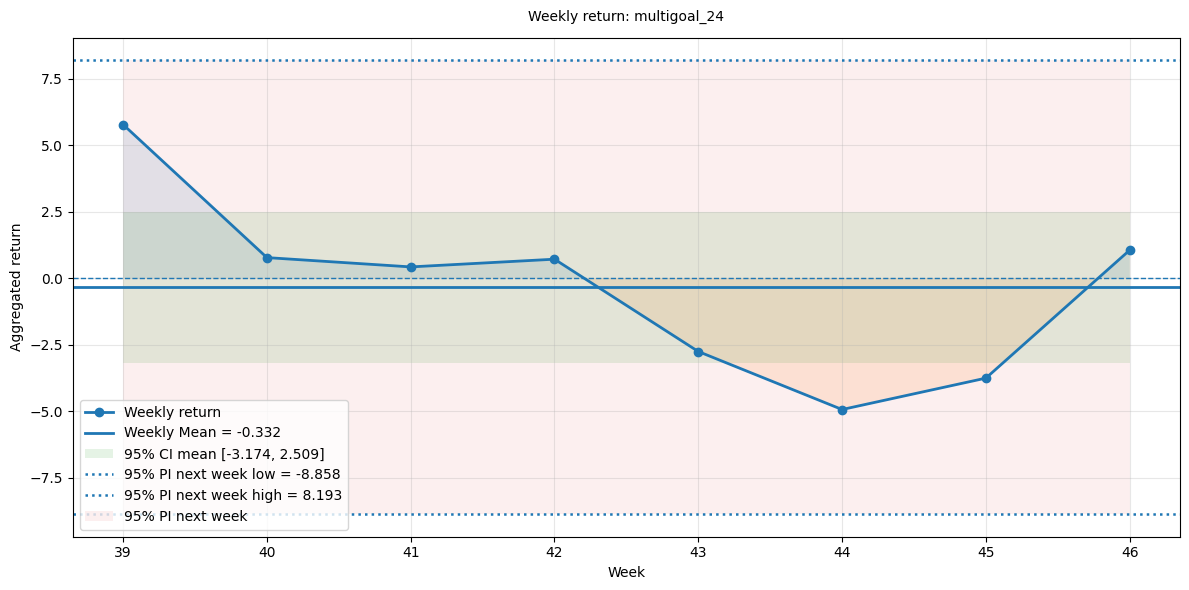

In [38]:
best_score_idx = 0

params_dict = best_trials[best_score_idx].user_attrs["params_dict"]

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]


mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Train ROI: {mean_roi}")
print(f"Train Accuracy: {accuracy} ({right}/{total})")


mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Test ROI: {mean_roi}")
print(f"Test Accuracy: {accuracy} ({right}/{total})")


df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [20]:
# Get Stats
weeks = stats["n_weeks"]
total_weeks = max(df["week"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")
weekly_stats = get_best_strategies(df_tot_filtered).iloc[0].to_dict()
weekly_stats["weeks_covered"] = np.round((weeks/total_weeks), 2)

get_best_strategies(df_tot_filtered)

No. of weeks covered: 38/45 (0.84)


,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
multigoal_24,-1.20,1.04,2.71,2.45,122,0.33


## 5. Save best Trials

In [ ]:
# Save best trials 
trial_to_save = best_trials[best_score_idx]

trial_to_save.set_user_attr("feature_bins_map", feature_bins_map)
trial_to_save.set_user_attr("weekly_stats", weekly_stats) 

study = optuna.create_study(
    study_name=f"{target_col}_aggregated_study",
    storage=os.getenv("OPTUNA_STORAGE"),
    direction="maximize",   
    load_if_exists=True,
)

existing = {trial_key(t) for t in study.trials if t.value is not None}

# esempio: best_frozen_trials = [study_seed_1.best_trial, study_seed_2.best_trial, ...]
new_best_trials = [
    t for t in [trial_to_save]
    if trial_key(t) not in existing
]

if new_best_trials:
    study.add_trials(new_best_trials)

print("Aggiunti:", len(new_best_trials))
print("Totale trial archiviati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

[I 2026-04-03 16:22:58,327] A new study created in RDB with name: over_15_aggregated_study


Aggiunti: 1
Totale trial archiviati: 1
Best assoluto: 2.428976876168547 {'underOver_chance_over15_use_min': True, 'underOver_chance_over15_use_max': True, 'underOver_chance_over15_min': 60, 'underOver_chance_over15_max': 90, 'underOver_comparison_affini_use_min': False, 'underOver_comparison_affini_use_max': True, 'underOver_comparison_affini_min': 3000, 'underOver_comparison_affini_max': 16000, 'underOver_comparison_flashback_use_min': False, 'underOver_comparison_flashback_use_max': True, 'underOver_comparison_flashback_min': 6000, 'underOver_comparison_flashback_max': 15000, 'underOver_flashback_over15_include_missing': False, 'underOver_flashback_over15_use_min': True, 'underOver_flashback_over15_use_max': False, 'underOver_flashback_over15_min': 76, 'underOver_flashback_over15_max': 92, 'evaluation_valUnderOver_cat_idx': 47}
